
✅ Ready for recommendations!


Do you want to search by Movie or Genre? (Enter 'movie' or 'genre'):  genre
Enter genre (e.g., Comedy, Drama):  action



🎬 Top 5 Movies in the genre 'action':
👉 Heat (1995)


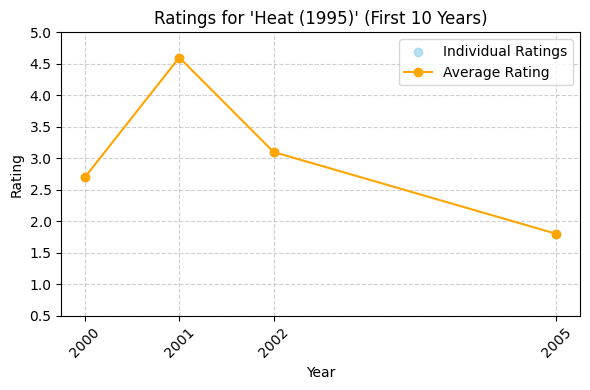

👉 Sudden Death (1995)


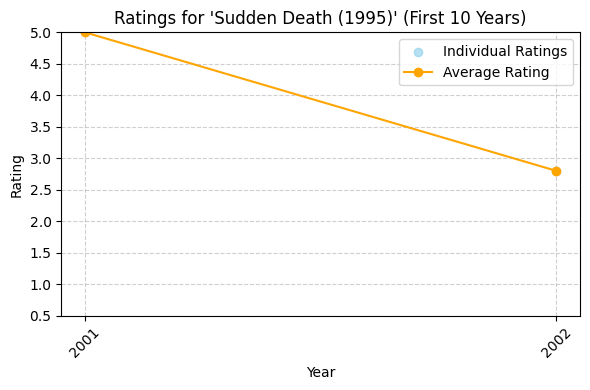

👉 GoldenEye (1995)


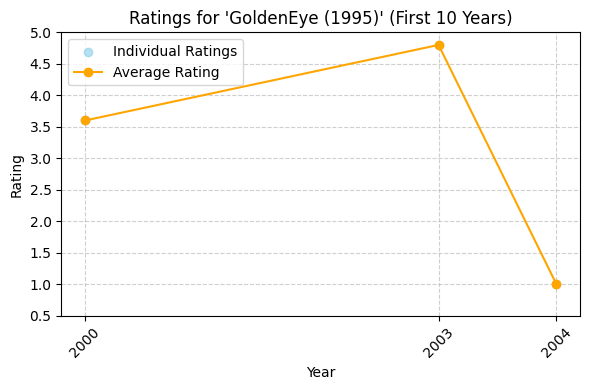

👉 Cutthroat Island (1995)
   📉 No ratings within first 10 years after release.
👉 Money Train (1995)


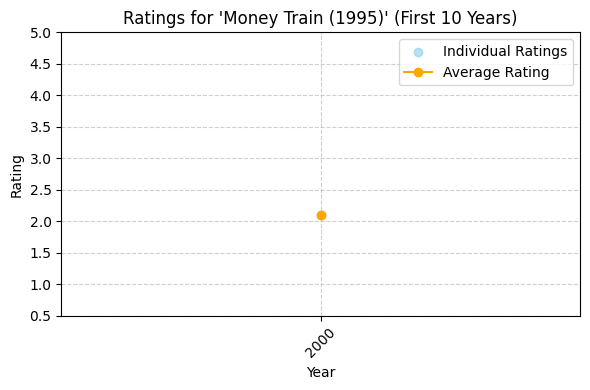

👉 Assassins (1995)


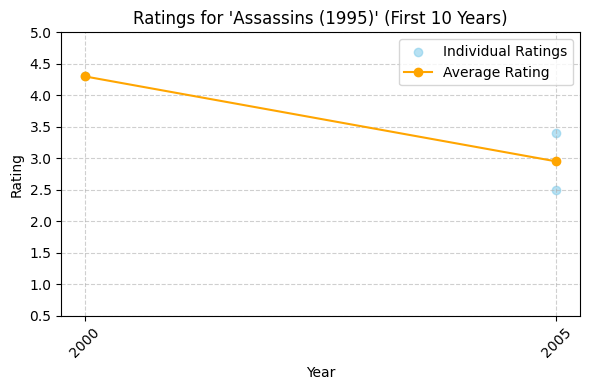

👉 Dead Presidents (1995)
   📉 No ratings within first 10 years after release.
👉 Mortal Kombat (1995)


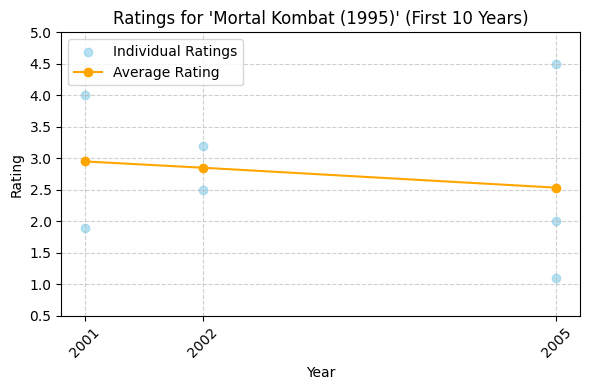

👉 Guardian Angel (1994)
   📉 No ratings within first 10 years after release.
👉 Lawnmower Man 2: Beyond Cyberspace (1996)


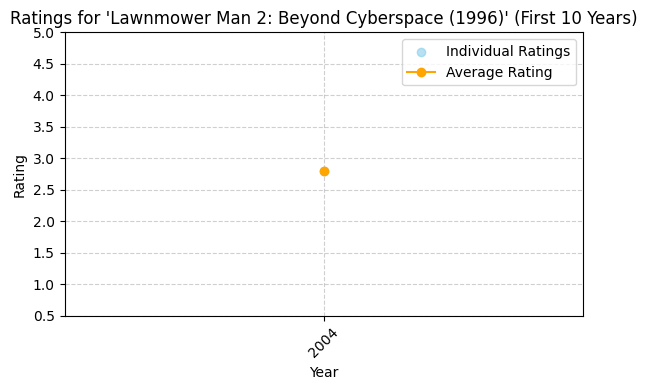

👉 From Dusk Till Dawn (1996)


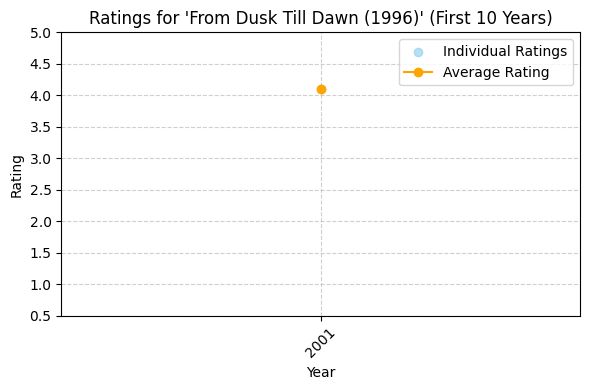

👉 Fair Game (1995)


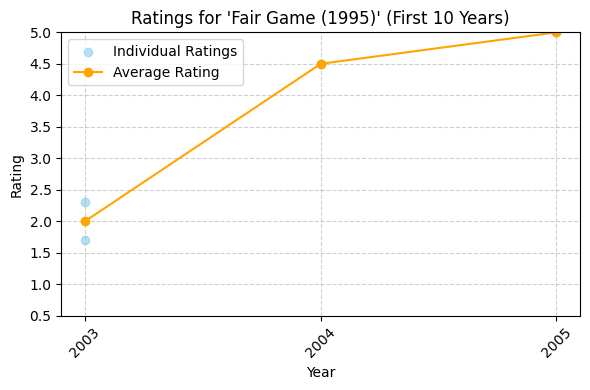

👉 Screamers (1995)
   📉 No ratings within first 10 years after release.
👉 Crossing Guard, The (1995)


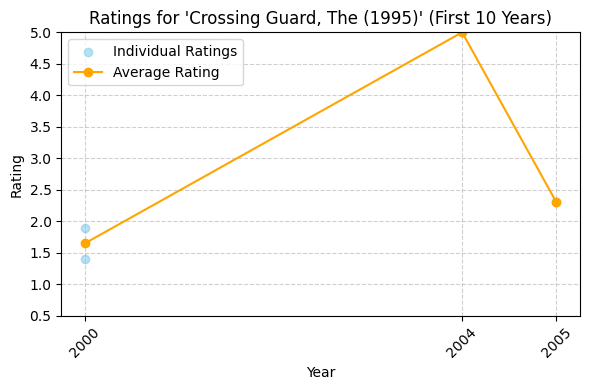

👉 White Squall (1996)


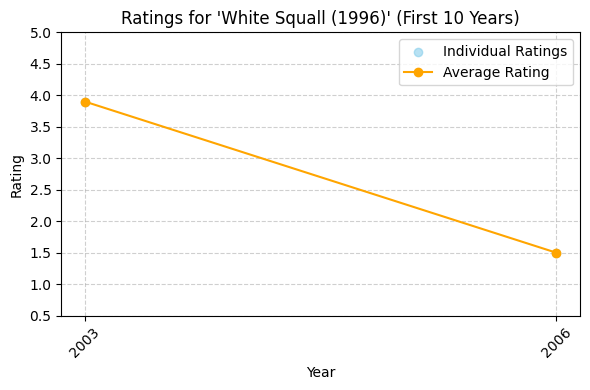

👉 Nick of Time (1995)


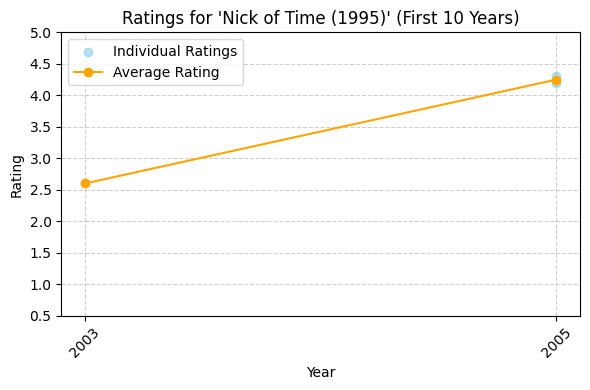

👉 Broken Arrow (1996)


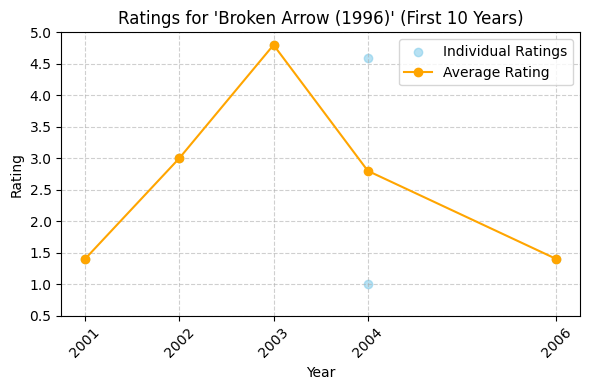

👉 Shopping (1994)


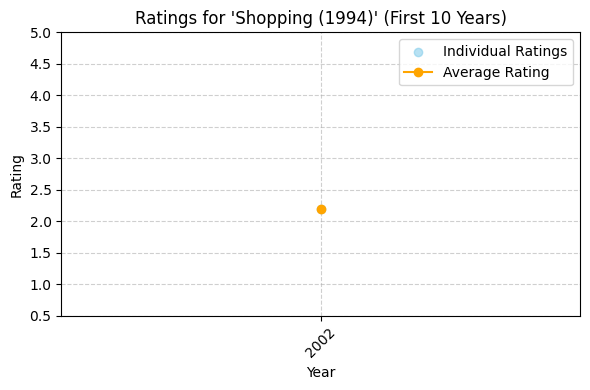

👉 Braveheart (1995)


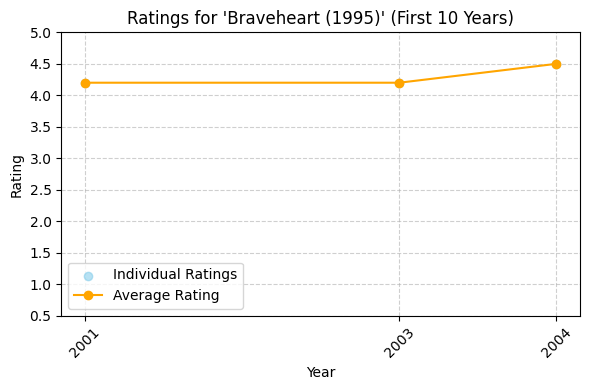

👉 Rumble in the Bronx (Hont faan kui) (1995)


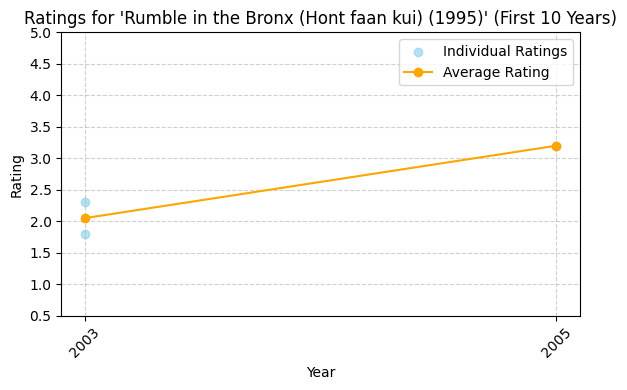

In [4]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import re

def parse_genres(genres):
    if isinstance(genres, str):
        try:
            genres_list = [g['name'] for g in ast.literal_eval(genres)]
            return " ".join(genres_list)
        except:
            return genres.replace('|', ' ')
    return ""

def get_release_year(title):
    """Extract release year from title if available."""
    match = re.search(r"\((\d{4})\)", title)
    if match:
        return int(match.group(1))
    return None


movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movies.dropna(inplace=True)
movies['tags'] = movies.apply(
    lambda row: f"{row['title']} {parse_genres(row['genres'])}".lower(),
    axis=1
)
movies = movies[movies['tags'].notnull()]
movies = movies[movies['tags'].str.strip() != ""]

new_df = movies[['movieId', 'title', 'tags']].copy()
new_df['tag_set'] = new_df['tags'].apply(lambda x: set(x.split()))

def jaccard_similarity(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    if union == 0:
        return 0
    return intersection / union

def similarity_to_stars(sim_score, max_stars=5):
    return f"{int(round(sim_score * max_stars))}/{max_stars}"

def plot_rating_distribution(movie_id, title):
    movie_ratings = ratings[ratings['movieId'] == movie_id].copy()
    if movie_ratings.empty:
        print("   📉 No ratings available for this movie.")
        return

    release_year = get_release_year(title)
    if not release_year:
        print("   📌 Release year not found in title.")
        return

    if 'timestamp' not in ratings.columns:
        print("   ❌ Ratings file has no timestamp column.")
        return

    movie_ratings['year'] = pd.to_datetime(movie_ratings['timestamp'], unit='s').dt.year
    movie_ratings = movie_ratings[movie_ratings['year'] <= release_year + 10]

    if movie_ratings.empty:
        print("   📉 No ratings within first 10 years after release.")
        return

    plt.figure(figsize=(6, 4))
    plt.scatter(movie_ratings['year'], movie_ratings['rating'], alpha=0.6, color="skyblue", label="Individual Ratings")
    avg_ratings = movie_ratings.groupby('year')['rating'].mean()
    plt.plot(avg_ratings.index, avg_ratings.values, color='orange', marker='o', label="Average Rating")

    plt.title(f"Ratings for '{title}' (First 10 Years)")
    plt.xlabel("Year")
    plt.ylabel("Rating")
    plt.xticks(avg_ratings.index, rotation=45)
    plt.ylim(0.5, 5.0)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show(block=True)

def recommend(movie):
    movie_lower = movie.lower()
    match = new_df[new_df['title'].str.lower() == movie_lower]
    if match.empty:
        print("❌ Movie not found! Check the title.")
        return
    movie_index = match.index[0]
    target_set = new_df.loc[movie_index, 'tag_set']
    similarities = []
    for idx, row in new_df.iterrows():
        if idx == movie_index:
            continue
        sim = jaccard_similarity(target_set, row['tag_set'])
        similarities.append((idx, sim))
    top5 = sorted(similarities, reverse=True, key=lambda x: x[1])[:5]

    print(f"\n🎬 Top 5 Recommended Movies similar to '{movie}':")
    for idx, sim in top5:
        movie_id = new_df.loc[idx, 'movieId']
        title = new_df.loc[idx, 'title']
        print(f"👉 {title} (Score: {similarity_to_stars(sim)})")
        plot_rating_distribution(movie_id, title)

def recommend_by_genre(genre):
    genre = genre.lower()
    matches = new_df[new_df['tags'].str.contains(genre)]
    if matches.empty:
        print(f"❌ No movies found for genre '{genre}'.")
    else:
        print(f"\n🎬 Top 5 Movies in the genre '{genre}':")
        for idx, row in matches.head(20).iterrows():
            title = row['title']
            movie_id = row['movieId']
            print("👉", title)
            plot_rating_distribution(movie_id, title)
print("\n✅ Ready for recommendations!")

choice = input("Do you want to search by Movie or Genre? (Enter 'movie' or 'genre'): ").strip().lower()

if choice == "movie":
    movie_name = input("Enter movie name with year (e.g., Toy Story (1995)): ").strip()
    recommend(movie_name)
elif choice == "genre":
    genre_name = input("Enter genre (e.g., Comedy, Drama): ").strip()
    recommend_by_genre(genre_name)
else:
    print("❌ Invalid choice. Please enter 'movie' or 'genre'.")

plt.show()